In [1]:
import scMPRAforge as scm
from dask.distributed import Client, LocalCluster
from pathlib import Path
import pandas as pd

2025-10-21 10:44:12.838179: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-21 10:44:12.861444: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /vast/palmer/apps/avx2/software/Code-Server/4.17.0/lib:/vast/palmer/apps/avx2/software/gettext/0.22.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/libiconv/1.17-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/ncurses/6.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/libxml2/2.12.7-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/XZ/5.4.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/expat/2.6.2-GCCcore-13.3.0/lib:/vast/palmer/apps/av

In [2]:
DATA_ROOT=Path("/gpfs/gibbs/pi/reilly/tabula_data")
path=DATA_ROOT/"simulated"
name="shendure_calibrated_sim_with_orthos_20251008"

In [3]:
cluster = LocalCluster(memory_limit='48G')
client = Client(cluster)

In [4]:
simu_obj=scm.de_novo_simulation.load(client,path=path,name=name)

In [5]:
def load_result(root: Path, hypothesis: str, test: str, replicate: int) -> pd.DataFrame:
    """Load a TSV result from the given directory structure."""
    path = root / hypothesis / test / str(replicate)
    if not path.exists():
        raise FileNotFoundError(f"No such file: {path}")
    return pd.read_csv(path, sep='\t')

In [ ]:
def merge_in_ground_truth(results,ground_truth):    
        merged=results.merge(ground_truth,
            left_on=["comparison_CRE","comparison_cell_type"],
            right_on=["cre_id","cell_type"]
        )
        
        merged=merged.drop(columns=["cre_id","cell_type"])
        merged=merged.rename({"true_mean":"comparison_truth"},axis=1)

        #merge in `reference` ground truth
        merged=merged.merge(ground_truth,
            left_on=["reference_CRE","reference_cell_type"],
            right_on=["cre_id","cell_type"]
        )
        merged=merged.drop(columns=["cre_id","cell_type"])
        merged=merged.rename({"true_mean":"reference_truth"},axis=1)

        #ground truth effect size
        merged["gt_effect_size"]=merged["comparison_truth"]/merged["reference_truth"]
        #ground truth null hypothesis that the CREs are the same : true or false?
        merged["gt_null"]=abs(merged["gt_effect_size"]-1)<1e-8

        merged["reject_null"]=merged["bh_p"]<0.05

        #godawful hack
        merged=merged.dropna(subset=["p_value"])

        return merged

In [20]:
ground_truth=simu_obj.ground_truth

records = []

for test in ["mwu", "wald"]:
    for hypothesis_set in ["hs_all_cre", "hs_all_ct"]:
        for replicate in range(5):
            ex = load_result(root=path/name/"results",
                                hypothesis=hypothesis_set,
                                test=test,
                                replicate=replicate)
            ex_merged = merge_in_ground_truth(results=ex,
                                                ground_truth=ex_ground_truth)
            ct = pd.crosstab(ex_merged["gt_null"], ex_merged["reject_null"])
            # Flatten the crosstab into a dict of counts
            for (gt, reject), count in ct.stack().items():
                records.append({
                    "test": test,
                    "hypothesis_set": hypothesis_set,
                    "replicate": replicate,
                    "gt_null": gt,
                    "reject_null": reject,
                    "count": count
                })

df = pd.DataFrame(records)
summary = (df.groupby(["test", "hypothesis_set", "gt_null", "reject_null"])
                ["count"]
                .agg(["mean", "std", "sum", "count"])
                .reset_index())

In [18]:
summary

,test,hypothesis_set,gt_null,reject_null,mean,std,sum,count
0,mwu,hs_all_cre,False,False,183.8,8.757854,919,5
1,mwu,hs_all_cre,False,True,1060.0,8.455767,5300,5
2,mwu,hs_all_ct,False,False,206.6,10.714476,1033,5
3,mwu,hs_all_ct,False,True,1245.2,10.639549,6226,5
4,wald,hs_all_cre,False,False,172.6,9.016651,863,5
5,wald,hs_all_cre,False,True,1072.2,8.786353,5361,5
6,wald,hs_all_ct,False,False,186.8,16.724234,934,5
7,wald,hs_all_ct,False,True,1067.2,69.969279,5336,5


In [21]:
records = []
for test in ["mwu", "wald"]:
    for hypothesis_set in ["hs_all_cre", "hs_all_ct"]:
        correct_fracs = []
        for replicate in range(5):
            ex = load_result(root=path/name/"results",
                                hypothesis=hypothesis_set,
                                test=test,
                                replicate=replicate)
            ex_merged = merge_in_ground_truth(results=ex,
                                                ground_truth=ex_ground_truth)

            # since gt_null is always False, "correct" means reject_null == True
            frac_correct = (ex_merged["reject_null"] == True).mean()
            correct_fracs.append(frac_correct)

        records.append({
            "test": test,
            "hypothesis_set": hypothesis_set,
            "mean_fraction_correct": pd.Series(correct_fracs).mean(),
            "std_fraction_correct": pd.Series(correct_fracs).std(),
        })

pd.DataFrame(records)

,test,hypothesis_set,mean_fraction_correct,std_fraction_correct
0,mwu,hs_all_cre,0.852228,0.007006
1,mwu,hs_all_ct,0.857694,0.007371
2,wald,hs_all_cre,0.861344,0.007217
3,wald,hs_all_ct,0.850859,0.012773


In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_p_vs_effect(hypothesis_set, test, replicate):
    ex = load_result(root=path/name/"results",
                     hypothesis=hypothesis_set,
                     test=test,
                     replicate=replicate)
    df = merge_in_ground_truth(results=ex, ground_truth=ex_ground_truth)

    # compute color by log10(max of comparison_truth and reference_truth)
    df["log_max_activity"] = np.log10(np.maximum(df["comparison_truth"], df["reference_truth"]).clip(lower=1e-12))

    # use a reversed warm colormap (small = red/yellow, large = blue)
    sns.scatterplot(data=df, x="gt_effect_size", y="p_value", hue="log_max_activity",
                    palette="inferno_r", alpha=0.6)

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Ground Truth Effect Size (log scale)")
    plt.ylabel("p-value (log scale)")
    plt.legend(title="log10(Max Activity)")
    plt.title(f"p-value vs Ground Truth Effect Size\n(test={test}, hypothesis_set={hypothesis_set}, replicate={replicate})")
    plt.tight_layout()
    plt.show()


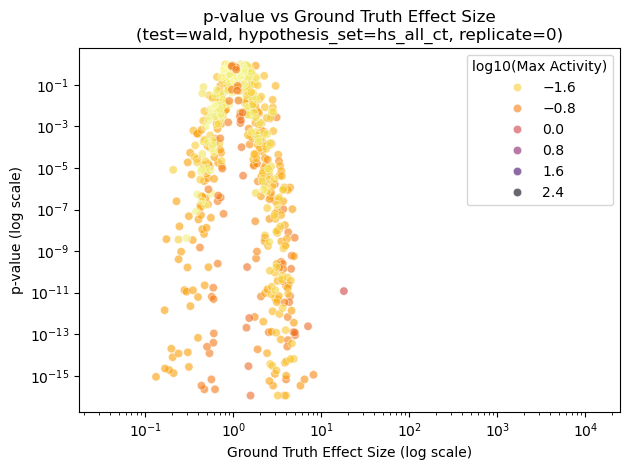

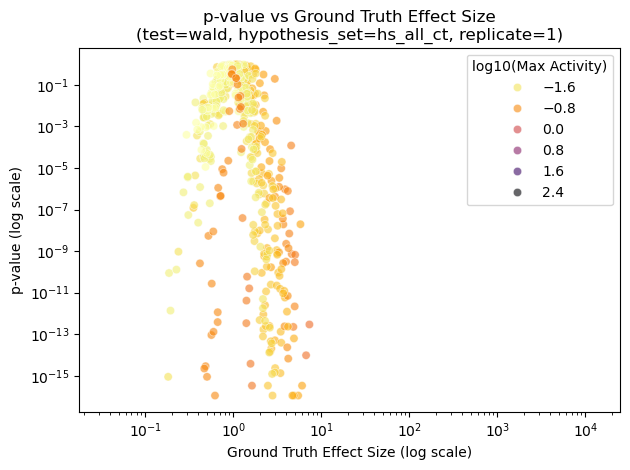

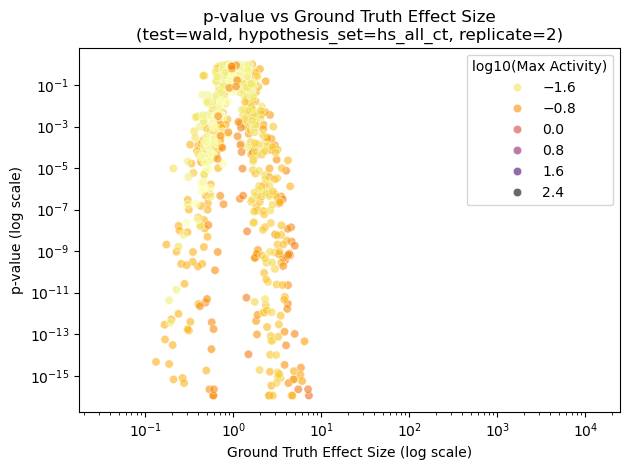

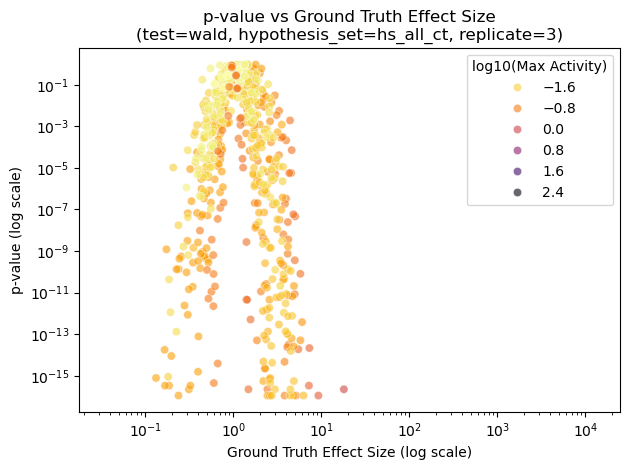

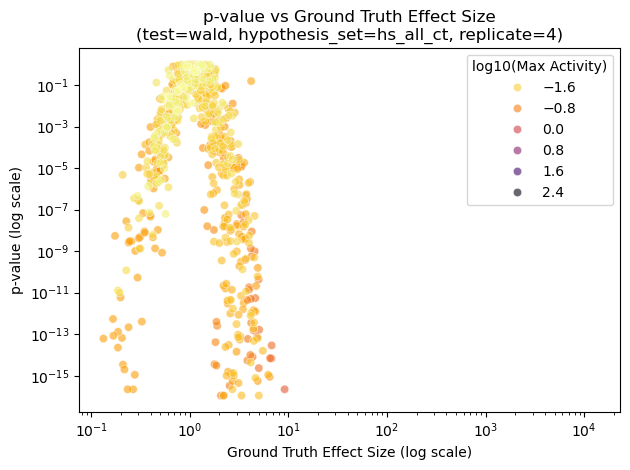

In [58]:
for replicate in range(5):
    plot_p_vs_effect(hypothesis_set="hs_all_ct",test="wald",replicate=replicate)

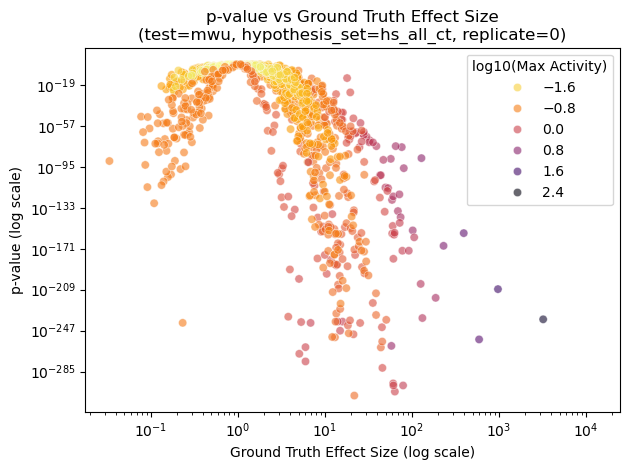

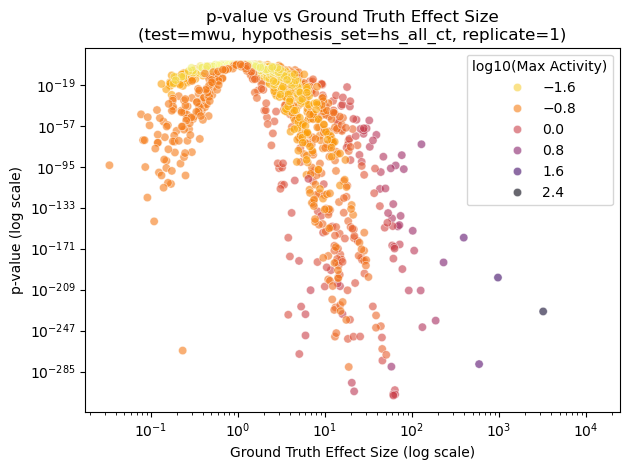

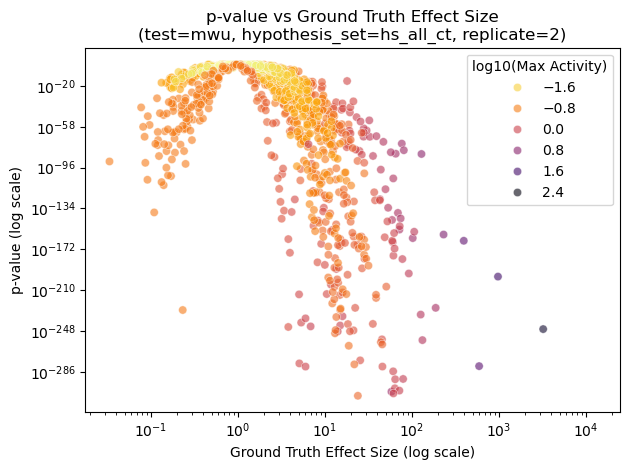

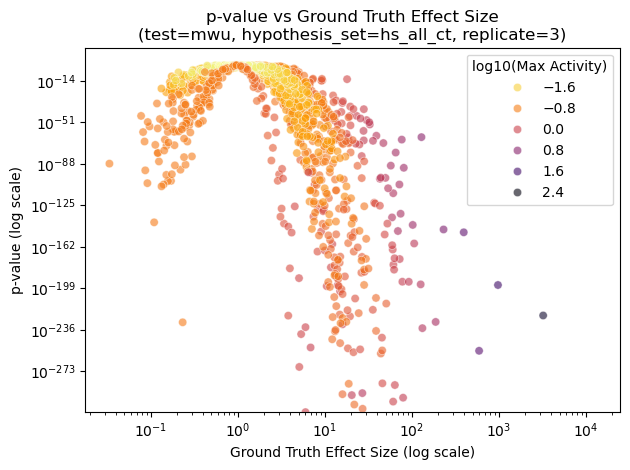

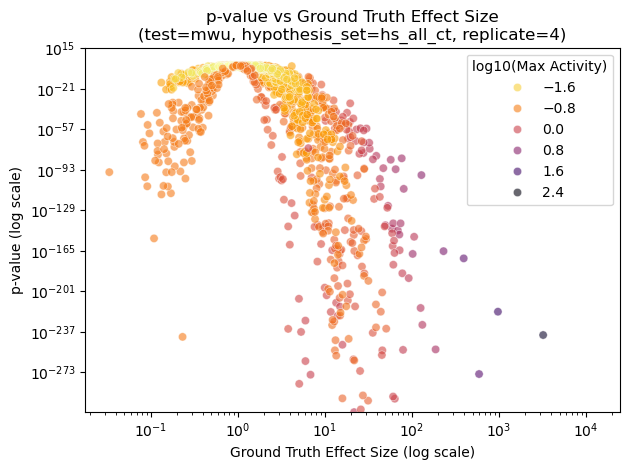

In [59]:
for replicate in range(5):
    plot_p_vs_effect(hypothesis_set="hs_all_ct",test="mwu",replicate=replicate)

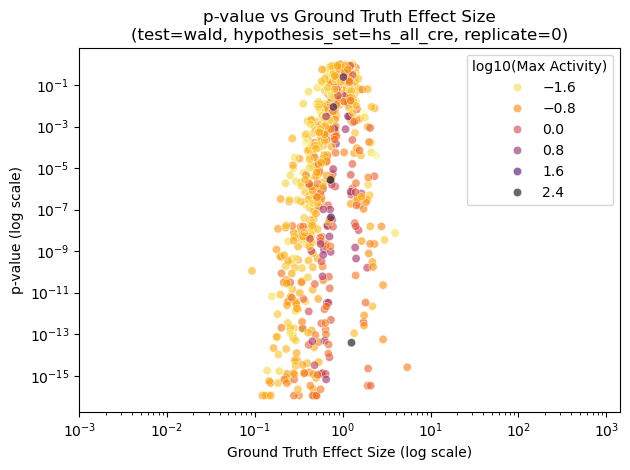

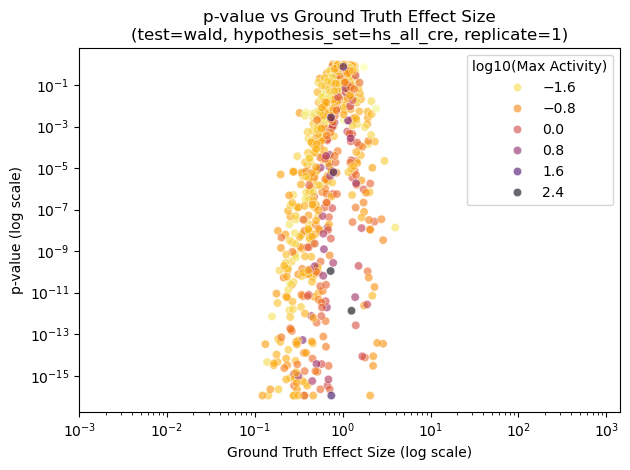

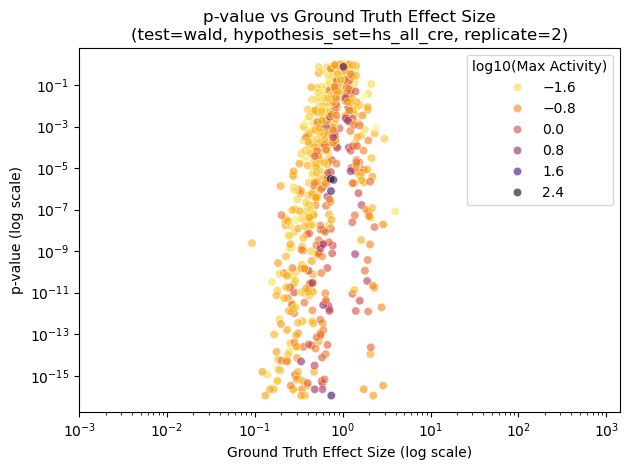

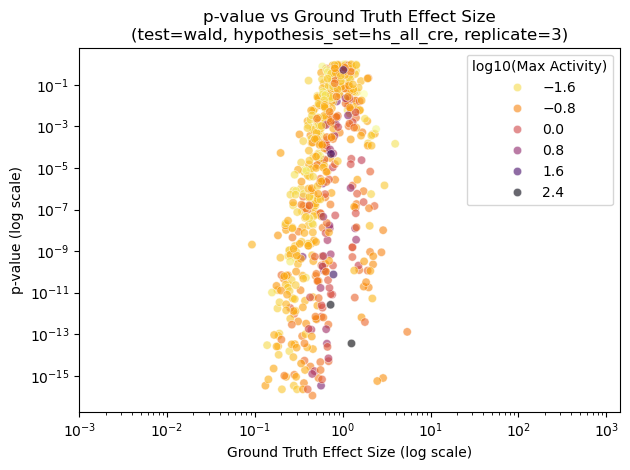

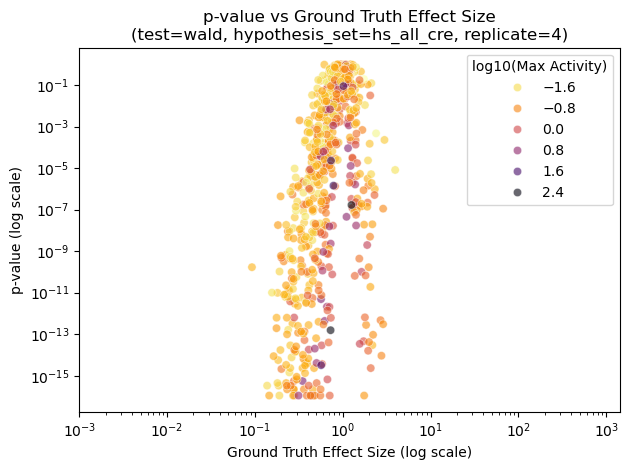

In [60]:
for replicate in range(5):
    plot_p_vs_effect(hypothesis_set="hs_all_cre",test="wald",replicate=replicate)

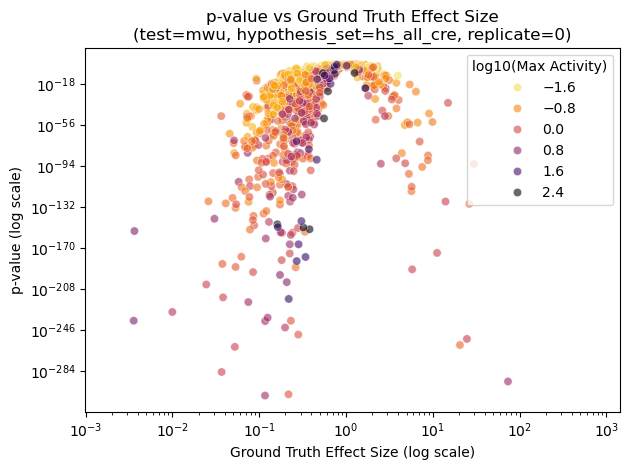

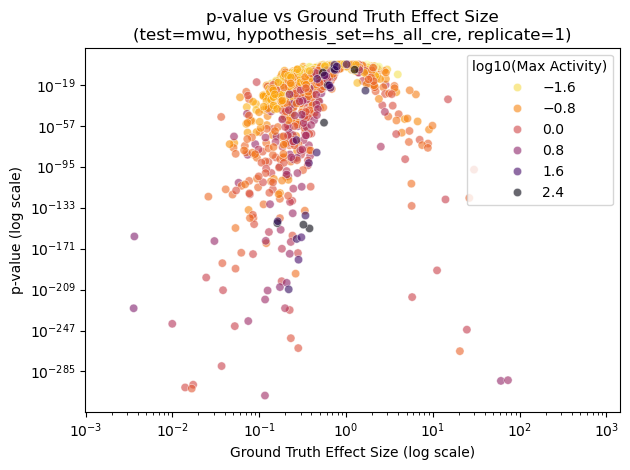

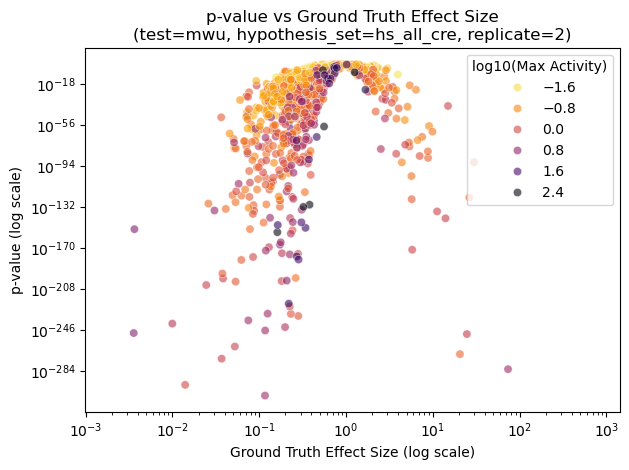

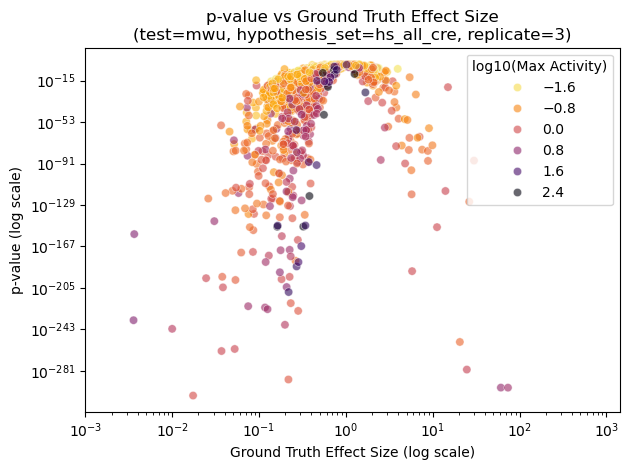

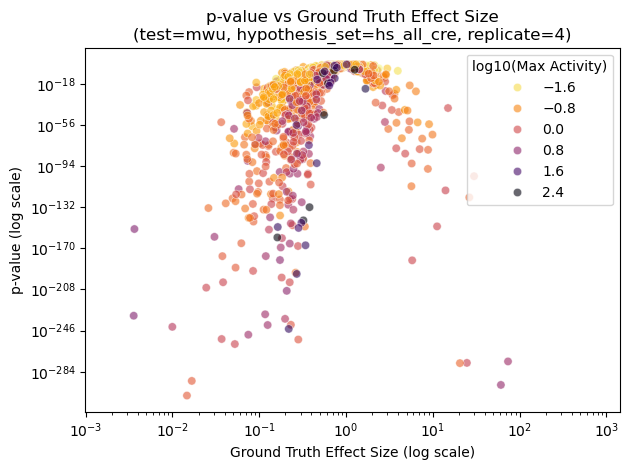

In [61]:
for replicate in range(5):
    plot_p_vs_effect(hypothesis_set="hs_all_cre",test="mwu",replicate=replicate)

In [51]:
ex_merged

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,test_type,bh_p,comparison_truth,reference_truth,gt_effect_size,gt_null,reject_null
0,Col1a2_chr6_77,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,1.222389,2.215606e-01,1.389442,False,wald,2.839417e-01,0.053783,0.045633,1.178605,False,False
1,Gata4_chr14_5760,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,6.892191,5.493939e-12,5.537543,False,wald,1.190627e-11,0.210918,0.045633,4.622074,False,True
2,Lamc1_chr1_12152,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,-3.817538,1.347899e-04,0.354883,False,wald,2.236742e-04,0.016147,0.045633,0.353838,False,True
3,Sparc_chr11_7195,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,6.719603,1.822209e-11,4.201281,False,wald,3.896683e-11,0.181964,0.045633,3.987582,False,True
4,Bend5_chr4_8174,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,1.971483,4.866868e-02,1.674415,False,wald,6.755921e-02,0.064510,0.045633,1.413687,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1241,Gata4_chr14_5677,SurfaceEctoderm,reference,SurfaceEctoderm,emvar_screen,23.760623,0.000000e+00,45.685803,False,wald,0.000000e+00,0.366307,0.007186,50.972941,False,True
1242,Col1a1_chr11_15276,SurfaceEctoderm,reference,SurfaceEctoderm,emvar_screen,15.182591,0.000000e+00,11.524346,False,wald,0.000000e+00,0.107705,0.007186,14.987585,False,True
1243,Lamc1_chr1_12127,SurfaceEctoderm,reference,SurfaceEctoderm,emvar_screen,6.244241,4.258630e-10,3.647586,False,wald,8.922844e-10,0.026493,0.007186,3.686638,False,True
1244,Sox17_chr1_65,SurfaceEctoderm,reference,SurfaceEctoderm,emvar_screen,2.929765,3.392183e-03,2.065326,False,wald,5.130677e-03,0.017960,0.007186,2.499170,False,True


In [ ]:
client.close()
cluster.close()